# 🌊 BinWaves GridI01(Propagation)

> **Inputs:**
> - Bathymetry file in `.nc` format, located in the `inputs/` folder.  
>
> **ℹ️ NOTE:** If bathymetry data for the study area is not available, free GEBCO bathymetry (~400 m resolution) can be used:
> - **Download GEBCO bathymetry data:** [https://download.gebco.net/](https://download.gebco.net/)
> - Example notebook for working with GEBCO data:  
>   [Download_GEBCO_Bathymetry_Data.ipynb](https://github.com/GeoOcean/BlueMath/blob/clean/binwaves/toolkit/data/Download_GEBCO_Bathymetry_Data.ipynb)
>
> **Outputs:**
> - SWAN case configuration in `.csv` format.
> - `Kp_coefficients.nc` file saved in the `outputs/` folder.
> 
> Create this `outputs/` folder if not available!

### BinWaves Notebooks Overview

This Jupyter Notebook is the first of three in the **BinWaves** modeling workflow, following Cagigal et al., 2024 :

1. `BinWaves_Propagation.ipynb`  
2. `BinWaves_Reconstruction.ipynb`  
3. `BinWaves_Validation.ipynb`

---

#### Before You Start

Make sure you have:

- Installed the latest version of `bluemath-tk`:  
  ```bash
  pip install bluemath-tk[waves]
  ```
 
---

<details open>
<summary><strong>📁 BinWaves_Propagation.ipynb</strong></summary>

This notebook constructs and runs the **library of pre-run cases** for all **monochromatic wave systems**.

</details>

---

<details>
<summary><strong>📁 BinWaves_Reconstruction.ipynb</strong></summary>

This notebook reconstructs **wave conditions** using **offshore directional wave spectra**.

##### Requirements:

- Offshore wave spectrum data (e.g., **CAWCR** or **ERA5** datasets).

- **OPTIONAL 1**: Apply **satellite corrections** to the hindcast spectrum before running BinWaves using the `CalVal` tool in the BlueMath toolkit. An example is provided in the Jupyter Notebook **P00A_CalVal_Carolinas_CAWCR_4469.ipynb**.

- **OPTIONAL 2**: A **Super Point Spectrum** can be also used as input to the hindcast spectrum before running BinWaves. The `SuperPoint` aggregates the energy from a number of points (Wave Spectra) surrounding the study site (Cagigal et al., 2021).  An example is provided in the Jupyter Notebook **Super Point Computation** .

</details>

---

<details>
<summary><strong>📁 BinWaves_Validation.ipynb</strong></summary>

This notebook performs **validation** using **wave buoy data**, if available.

##### Requirements:

- Wave buoy data in a format compatible with BinWaves (if available).
- Some wave buoy data can be freely downloaded from:  
  🌊 [https://www.ndbc.noaa.gov/](https://www.ndbc.noaa.gov/)

- **NOTE:** You can use the `NDBC_buoy_data.ipynb` notebook to:
  - Download the buoy data.
  - Convert it into the appropriate format for BinWaves.

</details>

### 📌 In This Notebook: `BinWaves_Propagation.ipynb`

This notebook handles the **construction of the wave propagation library** by simulating wave cases.

### Steps:

- Generate wave conditions for all specified **frequencies** and **directions**.
- Set up and run SWAN simulations.
- Extract and save outputs from each simulation.
- Visualize the full wave library, including larger illustrative examples.

> ⚠️ **Coordinate System Note**  
> The BinWaves (SWAN) model can run in either **Spherical** or **Cartesian** coordinates:
> - Use **spherical coordinates** for areas larger than **100 km**.
> - Make sure your bathymetry file matches the coordinate system used in your simulation.

## Generate computational bathymetry

> ⚠️ **NOTE**  
> 
> - Functions expect coordinate columns to follow standard naming conventions.
> - For geographic coordinates, use: 'lon', 'lat', 'longitude', or 'latitude'.
> - For UTM coordinates, use: 'x', 'y', 'X', 'Y', 'cx', 'cy', 'easting', or 'northing'.
> - Ensure your data uses one of these names—otherwise, rename the coordinates accordingly
> - The bathymetry should have positive values for sea and negative values for land.

In [1]:
import xarray as xr
import sys
sys.path.append('../utils')
from plotting import detect_coordinate_system
ds = xr.open_dataset("../inputs/gebco_bathymetry.nc")
coords = detect_coordinate_system(ds)
is_geographic = coords["is_geographic"]
x_coord = coords["x_coord"]
y_coord = coords["y_coord"]

bathy = -(ds.transpose(y_coord, x_coord).sortby(y_coord, ascending=False).elevation)
bathy

<xarray.DataArray 'elevation' (lat: 1342, lon: 1533)> Size: 4MB
array([[-297, -278, -270, ..., 2808, 2810, 2813],
       [-273, -282, -270, ..., 2811, 2812, 2812],
       [-272, -256, -254, ..., 2814, 2815, 2813],
       ...,
       [  64,   65,   65, ..., 5320, 5322, 5322],
       [  65,   66,   65, ..., 5322, 5322, 5322],
       [  66,   66,   66, ..., 5325, 5324, 5322]],
      shape=(1342, 1533), dtype=int16)
Coordinates:
  * lat      (lat) float64 11kB 37.57 37.57 37.56 37.56 ... 31.99 31.99 31.99
  * lon      (lon) float64 12kB -79.39 -79.39 -79.39 ... -73.02 -73.01 -73.01
Attributes:
    standard_name:       height_above_mean_sea_level
    long_name:           Elevation relative to sea level
    units:               m
    grid_mapping:        crs
    sdn_parameter_urn:   SDN:P01::BATHHGHT
    sdn_parameter_name:  Sea floor height (above mean sea level) {bathymetric...
    sdn_uom_urn:         SDN:P06::ULAA
    sdn_uom_name:        Metres

In [2]:
# Crop bathymetry
cropped_bathy = bathy.sel(lat=slice(37.5, 33.55), lon=slice(-80,-74))
cropped_bathy.to_netcdf("outputs/bathy.nc")
cropped_bathy

<xarray.DataArray 'elevation' (lat: 948, lon: 1295)> Size: 2MB
array([[-265, -274, -289, ..., 1459, 1477, 1493],
       [-284, -296, -314, ..., 1467, 1481, 1494],
       [-296, -314, -358, ..., 1479, 1489, 1500],
       ...,
       [  -8,  -18,  -20, ..., 4539, 4535, 4530],
       [  -9,  -13,  -15, ..., 4538, 4534, 4530],
       [  -7,   -6,   -6, ..., 4537, 4533, 4532]],
      shape=(948, 1295), dtype=int16)
Coordinates:
  * lat      (lat) float64 8kB 37.5 37.49 37.49 37.49 ... 33.56 33.56 33.55
  * lon      (lon) float64 10kB -79.39 -79.39 -79.39 ... -74.01 -74.01 -74.0
Attributes:
    standard_name:       height_above_mean_sea_level
    long_name:           Elevation relative to sea level
    units:               m
    grid_mapping:        crs
    sdn_parameter_urn:   SDN:P01::BATHHGHT
    sdn_parameter_name:  Sea floor height (above mean sea level) {bathymetric...
    sdn_uom_urn:         SDN:P06::ULAA
    sdn_uom_name:        Metres

In [3]:
def get_buoy_coords(buoys):
    """Extract coordinates from buoys, whether dict or iterable of tuples."""
    if isinstance(buoys, dict):
        return np.array(list(buoys.values()))
    else:
        return np.array(list(buoys))

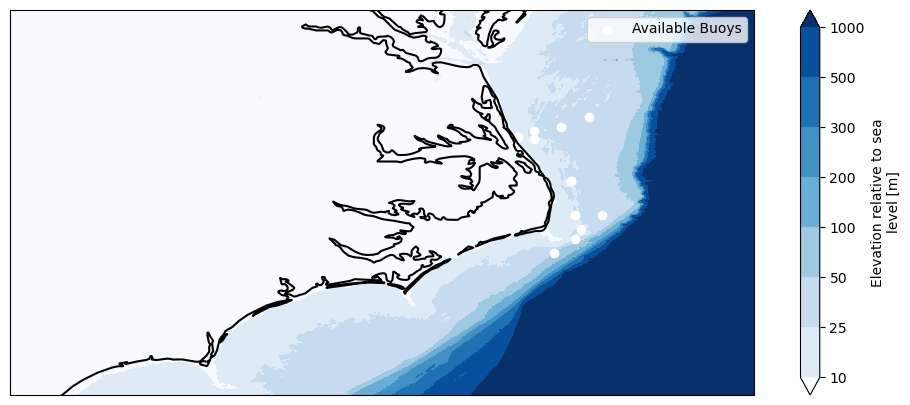

In [4]:
from plotting import plot_selected_bathy

# if NOT buoys or other locations of interest just run plot_selected_bathy(bathy=bathy)

buoys_geo = {
    "jprn7": (-75.5870, 35.9120),
    "41017": (-75.1000, 35.4000),
    "41015": (-75.3000, 35.4000),
    "41120": (-75.2580, 35.2580),
    "dsln7": (-75.2970, 35.1530),
    "41025": (-75.4540, 35.0100),
    "44095": (-75.3300, 35.7500),
    "44086": (-75.3300, 35.7500),
    "41025": (-75.4540, 35.0100),
    "44006": (-75.4000, 36.3000),
    "44079": (-75.5930, 36.1750),
    "44056": (-75.7140, 36.2000),
    '44100': (-75.5930, 36.2580),
    "44019": (-75.2000, 36.4000),
   
}



plot_selected_bathy(bathy=cropped_bathy, buoys=buoys_geo)

## SWAN Grid Parameters

This section defines the computational grid for running the SWAN model:

- **`xpc`, `ypc`**: Origin coordinates of the grid (in meters for Cartesian, degrees for spherical).  
  - Default = `0.0` for Cartesian; required for spherical.

- **`alpc`**: Angle of the positive x-axis (degrees, Cartesian convention).  
  - Default = `0.0`.

- **`xlenc`, `ylenc`**: Grid length in the x- and y-directions.  
  - Units: meters (Cartesian), degrees (spherical).  

- **`mxc`, `myc`**: Number of grid cells in x- and y-directions (1 less than number of grid points).  
  - In 1D mode, `myc` = `0`.

<center>
    <img src="./assets/SWAN_grid.png" width="80%">
</center>

## Grid Parameters

In [5]:
xpc = -76.3001
ypc =  34.2551
alpc = 41
xlenc = 1.8
ylenc =2

In [6]:
from bluemath_tk.topo_bathy.swan_grid import generate_grid_parameters

grid_parameters, cropped_bathy, corners = generate_grid_parameters(
   cropped_bathy, alpc, xpc, ypc, xlenc, ylenc, buffer_distance=1
)
grid_parameters

Cropping bounds: x=[-78.61221805798101, -73.94162275559901], y=[33.2551, 37.94542541262845]


{'xpc': -76.3001,
 'ypc': 34.2551,
 'alpc': 41,
 'xlenc': 1.8,
 'ylenc': 2,
 'mxc': 431,
 'myc': 479,
 'xpinp': np.float64(-78.61041666666667),
 'ypinp': np.float64(33.55208333333333),
 'alpinp': 0,
 'mxinp': 1106,
 'myinp': 947,
 'dxinp': np.float64(0.004166666666662877),
 'dyinp': np.float64(0.004166666666677088)}

## Desired locations for Model outputs

> ⚠️ **NOTE**  
> 
> - Output location spacing (out_dx, out_dy) can be specified. If not provided, the output locations will use the same spacing as the SWAN grid. However, for large domains or very fine SWAN grids, it is recommended to decrease the output spacing to reduce computational cost, at least at tasting stages.

## Crop output with 10m depth countour

In [7]:
# polygon =        [
#     [grid_parameters['xpc']    ,  grid_parameters['ypc']   ],
#     [grid_parameters['xpc']+grid_parameters['xlenc'],  grid_parameters['ypc']   ],
#     [grid_parameters['xpc']+grid_parameters['xlenc'],  grid_parameters['ypc']+grid_parameters['ylenc']],
#     [grid_parameters['xpc']    ,  grid_parameters['ypc']+grid_parameters['ylenc']],
#     [grid_parameters['xpc']    ,  grid_parameters['ypc']   ]
# ]
# Create a Path object for the polygon
from matplotlib.path import Path
polygon = Path(corners)
polygon

Path(array([[-76.3001    ,  34.2551    ],
       [-74.94162276,  35.43600625],
       [-76.25374081,  36.94542541],
       [-77.61221806,  35.76451916],
       [-76.3001    ,  34.2551    ]]), None)

ANSWER: New origin coordinates
Original origin (red circle): xpc = -76.300100°, ypc = 34.255100°
NEW origin (orange point):    xpc = -76.752926°, ypc = 33.861465°

Original xlenc:  1.8°
New xlenc:       2.4°
ylenc (unchanged): 2°
alpc (PRESERVED):  41°

Shift: Δx = -0.452826°, Δy = -0.393635°


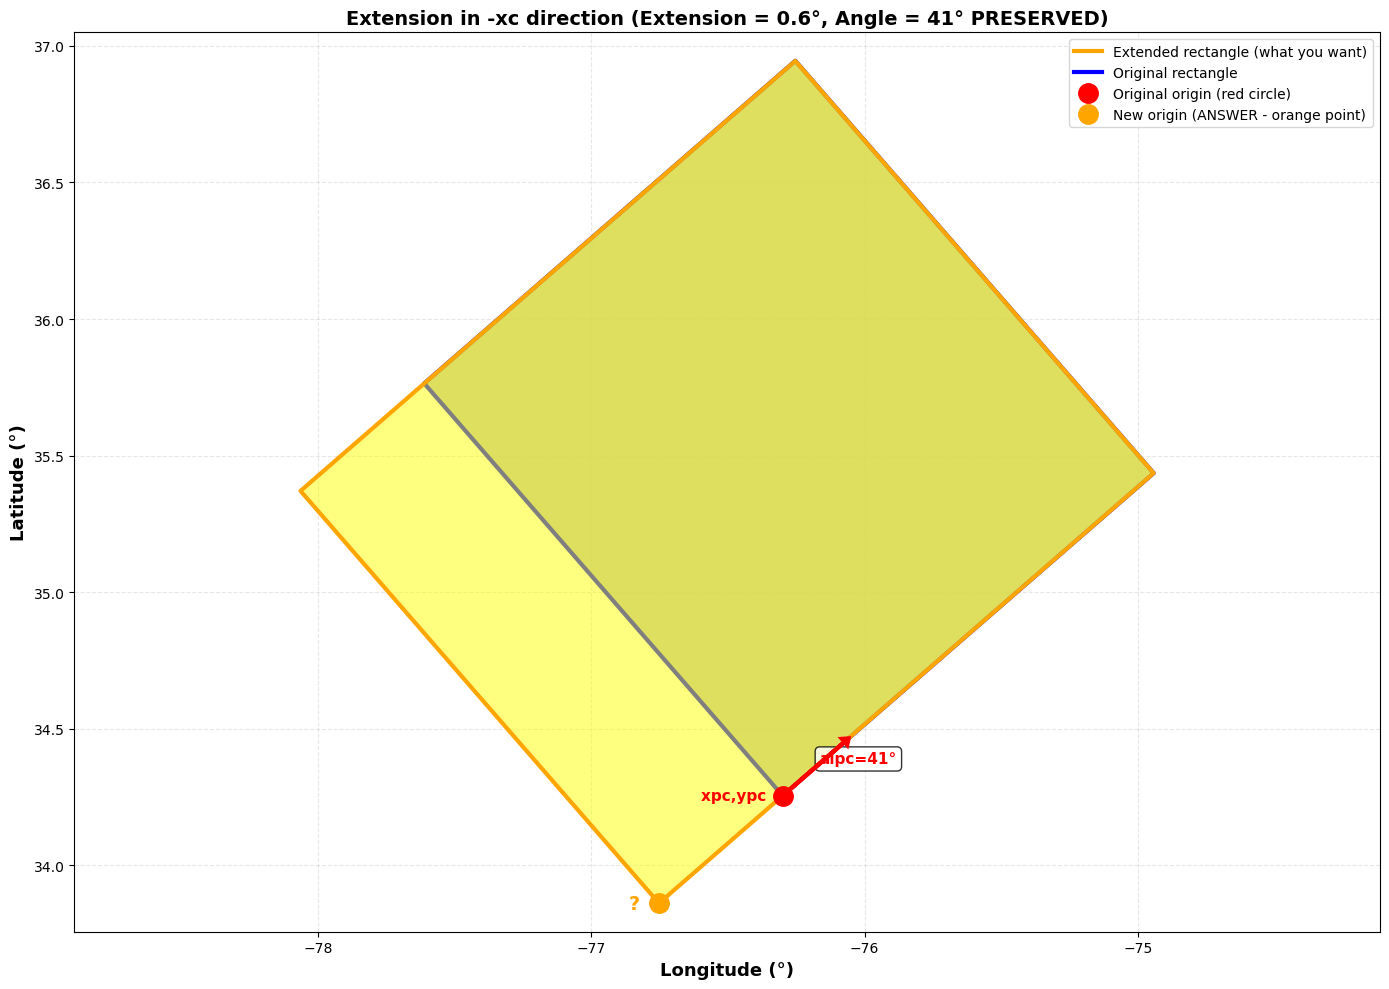

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Extension amount (in degrees)
extension = .6 # 1 degree

# Convert angle to radians
alpc_rad = np.radians(alpc)

# To extend in the NEGATIVE xc direction (opposite to alpc arrow)
# We move the origin at angle (alpc + 180)
angle_extension = np.radians(alpc + 180)

# Calculate NEW origin (the orange point you want)
xpc_new = xpc + extension * np.cos(angle_extension)
ypc_new = ypc + extension * np.sin(angle_extension)

# New xlenc (extended by 1 degree in xc direction)
xlenc_new = xlenc + extension
ylenc_new = ylenc  # unchanged

# Function to create rectangle corners
def get_rectangle_corners(xpc, ypc, alpc, xlenc, ylenc):
    """Get the corners of the rotated rectangle in problem coordinates"""
    alpc_rad = np.radians(alpc)
    
    corners_local = np.array([
        [0, 0],
        [xlenc, 0],
        [xlenc, ylenc],
        [0, ylenc],
        [0, 0]
    ])
    
    corners_problem = []
    for xc, yc in corners_local:
        xp = xpc + xc * np.cos(alpc_rad) - yc * np.sin(alpc_rad)
        yp = ypc + xc * np.sin(alpc_rad) + yc * np.cos(alpc_rad)
        corners_problem.append([xp, yp])
    
    return np.array(corners_problem)

# Get corners for both rectangles
corners_original = get_rectangle_corners(xpc, ypc, alpc, xlenc, ylenc)
corners_new = get_rectangle_corners(xpc_new, ypc_new, alpc, xlenc_new, ylenc_new)

# Create the plot
plt.figure(figsize=(14, 10))

# Plot extended rectangle (YELLOW - what you want)
plt.plot(corners_new[:, 0], corners_new[:, 1], 
         'orange', linewidth=3, label='Extended rectangle (what you want)', zorder=4)
plt.fill(corners_new[:, 0], corners_new[:, 1], 
         color='yellow', alpha=0.5, zorder=3)

# Plot original rectangle (blue/gray)
plt.plot(corners_original[:, 0], corners_original[:, 1], 
         'b-', linewidth=3, label='Original rectangle', zorder=2)
plt.fill(corners_original[:, 0], corners_original[:, 1], 
         color='gray', alpha=0.5, zorder=1)

# Plot origin points
plt.plot(xpc, ypc, 'ro', markersize=14, 
         label=f'Original origin (red circle)', zorder=6)
plt.plot(xpc_new, ypc_new, 'o', color='orange', markersize=14, 
         label=f'New origin (ANSWER - orange point)', zorder=6)

# Add text labels
plt.text(xpc-0.02, ypc, 'xpc,ypc  ', fontsize=11, fontweight='bold', 
         ha='right', va='center', color='red')
plt.text(xpc_new-0.02, ypc_new, '?  ', fontsize=14, fontweight='bold', 
         ha='right', va='center', color='orange')

# Add axis direction arrow from ORIGINAL origin
arrow_length = 0.3
plt.arrow(xpc, ypc, arrow_length * np.cos(alpc_rad), 
          arrow_length * np.sin(alpc_rad),
          head_width=0.03, head_length=0.02, fc='red', ec='red', 
          linewidth=3, zorder=5)
plt.text(xpc + arrow_length * np.cos(alpc_rad) * 0.6, 
         ypc + arrow_length * np.sin(alpc_rad) * 0.6, 
         f'alpc={alpc}°', fontsize=11, fontweight='bold', color='red',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Labels and formatting
plt.xlabel('Longitude (°)', fontsize=13, fontweight='bold')
plt.ylabel('Latitude (°)', fontsize=13, fontweight='bold')
plt.title(f'Extension in -xc direction (Extension = {extension}°, Angle = {alpc}° PRESERVED)', 
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.axis('equal')
plt.tight_layout()

# Print the answer
print("="*60)
print("ANSWER: New origin coordinates")
print("="*60)
print(f"Original origin (red circle): xpc = {xpc:.6f}°, ypc = {ypc:.6f}°")
print(f"NEW origin (orange point):    xpc = {xpc_new:.6f}°, ypc = {ypc_new:.6f}°")
print(f"\nOriginal xlenc:  {xlenc}°")
print(f"New xlenc:       {xlenc_new}°")
print(f"ylenc (unchanged): {ylenc}°")
print(f"alpc (PRESERVED):  {alpc}°")
print(f"\nShift: Δx = {xpc_new - xpc:.6f}°, Δy = {ypc_new - ypc:.6f}°")
print("="*60)

In [9]:
# Original parameters
xpc = xpc_new
ypc = ypc_new
alpc = alpc # angle in degrees - PRESERVED
xlenc = xlenc+extension*2
ylenc = ylenc

In [10]:
from bluemath_tk.topo_bathy.swan_grid import generate_grid_parameters

grid_parameters, cropped_bathy, corners = generate_grid_parameters(
   cropped_bathy, alpc, xpc, ypc, xlenc, ylenc, buffer_distance=1
)
grid_parameters

Cropping bounds: x=[-79.06504380611467, -73.48879700746535], y=[32.86146458260569, 38.33906083002276]


{'xpc': np.float64(-76.75292574813366),
 'ypc': np.float64(33.86146458260569),
 'alpc': 41,
 'xlenc': 3.0,
 'ylenc': 2,
 'mxc': 719,
 'myc': 479,
 'xpinp': np.float64(-78.61041666666667),
 'ypinp': np.float64(33.55208333333333),
 'alpinp': 0,
 'mxinp': 1106,
 'myinp': 947,
 'dxinp': np.float64(0.004166666666662877),
 'dyinp': np.float64(0.004166666666677088)}

In [11]:
# Create a Path object for the polygon
from matplotlib.path import Path
polygon = Path(corners)
polygon

Path(array([[-76.75292575,  33.86146458],
       [-74.48879701,  35.82964167],
       [-75.80091507,  37.33906083],
       [-78.06504381,  35.37088374],
       [-76.75292575,  33.86146458]]), None)

In [12]:
# For isobath points
import geopandas as gpd
import json
import numpy as np
geojson_path = '../inputs/isobath_10m_points_500m.geojson'

# If using geopandas
import geopandas as gpd
gdf = gpd.read_file(geojson_path)
gdf['lon'] = gdf.geometry.x
gdf['lat'] = gdf.geometry.y

# Extract all points as array
isobath_all_points = np.array(list(zip(gdf['lon'], gdf['lat'])))

# Check which points are inside the polygon
isobath_inside_mask = polygon.contains_points(isobath_all_points)
isobath_points_in_area = isobath_all_points[isobath_inside_mask]

print(f"Total isobath points: {len(isobath_all_points)}")
print(f"Isobath points inside polygon: {len(isobath_points_in_area)}")

Total isobath points: 2244
Isobath points inside polygon: 1125


In [13]:
# OUTPUT GRID LOCATIONS (KPS)
import numpy as np
from operations import locations_grid_outputs

locations = locations_grid_outputs(grid_parameters, out_dx=0.135*3, out_dy=0.1*3 )
# Combine grid locations with buoy locations
buoy_coords = get_buoy_coords(buoys_geo)
locations = np.vstack((locations, buoy_coords))
# Add isobath points
locations = np.vstack((locations, isobath_points_in_area))

print(f"Total locations (grid + buoys + isobath): {len(locations)}")

Total locations (grid + buoys + isobath): 1210


In [14]:
# Load the WHACS points JSON file
outputs_3km_path = '../inputs/outputs_3km.json'
with open(outputs_3km_path, 'r') as f:
    outputs_3km_data = json.load(f)

# Extract all WHACS points
all_outputs_3km_points = []
all_outputs_3km_ids = []

for feature in outputs_3km_data['features']:
    lon, lat = feature['geometry']['coordinates']
    all_outputs_3km_points.append((lon, lat))
    all_outputs_3km_ids.append(feature['properties']['id'])

all_outputs_3km_points = np.array(all_outputs_3km_points)

print(f"Total outputs 3km points in file: {len(all_outputs_3km_points)}")

# Check which points are inside the polygon
points_inside_mask = polygon.contains_points(all_outputs_3km_points)
outputs_3km_points_in_area = all_outputs_3km_points[points_inside_mask]
outputs_3km_ids_in_area = [all_outputs_3km_ids[i] for i in range(len(all_outputs_3km_ids)) if points_inside_mask[i]]

print(f"outputs 3km points inside polygon: {len(outputs_3km_points_in_area)}")

# Subsample if needed
subsample_step = 1  # Set to 1 for all points, or higher to subsample
outputs_3km_points_array = outputs_3km_points_in_area[::subsample_step]

print(f"outputs 3km points after subsampling (every {subsample_step}): {len(outputs_3km_points_array)}")
locations = np.vstack((locations, outputs_3km_points_array))
print(f"Total locations (grid + buoys + isobath + 3km): {len(locations)}")

Total outputs 3km points in file: 1246
outputs 3km points inside polygon: 765
outputs 3km points after subsampling (every 1): 765
Total locations (grid + buoys + isobath + 3km): 1975


In [15]:
# Load the WHACS points JSON file
whacs_path = '../inputs/WHACS_NorthCarolina_points.json'
with open(whacs_path, 'r') as f:
    whacs_data = json.load(f)

# Extract all WHACS points
all_whacs_points = []
all_whacs_ids = []

for feature in whacs_data['features']:
    lon, lat = feature['geometry']['coordinates']
    all_whacs_points.append((lon, lat))
    all_whacs_ids.append(feature['properties']['id'])

all_whacs_points = np.array(all_whacs_points)

print(f"Total WHACS points in file: {len(all_whacs_points)}")

# Check which points are inside the polygon
points_inside_mask = polygon.contains_points(all_whacs_points)
whacs_points_in_area = all_whacs_points[points_inside_mask]
whacs_ids_in_area = [all_whacs_ids[i] for i in range(len(all_whacs_ids)) if points_inside_mask[i]]

print(f"WHACS points inside polygon: {len(whacs_points_in_area)}")

# Subsample if needed
subsample_step = 1  # Set to 1 for all points, or higher to subsample
whacs_points_array = whacs_points_in_area[::subsample_step]

print(f"WHACS points after subsampling (every {subsample_step}): {len(whacs_points_array)}")
locations = np.vstack((locations, whacs_points_array))
print(f"Total locations (grid + buoys + isobath + 3km + WHACS): {len(locations)}")

Total WHACS points in file: 1734
WHACS points inside polygon: 676
WHACS points after subsampling (every 1): 676
Total locations (grid + buoys + isobath + 3km + WHACS): 2651


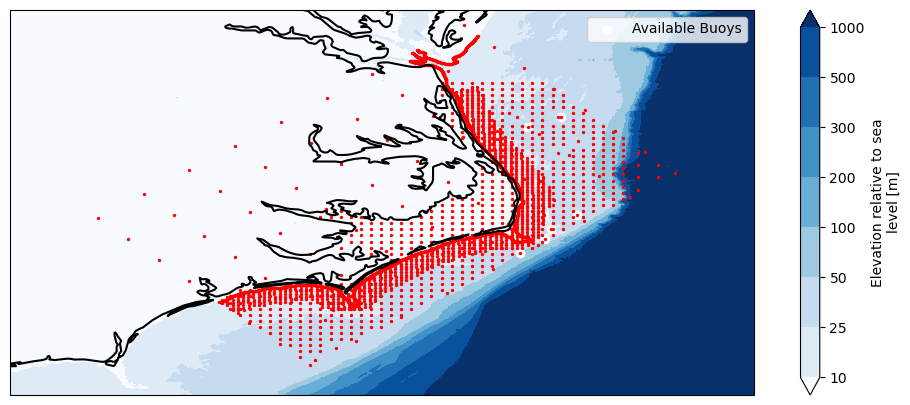

In [16]:
import matplotlib.pyplot as plt
from plotting import plot_selected_bathy, detect_coordinate_system

# Get the projection from your bathy
coords = detect_coordinate_system(bathy)
proj = coords["proj"]
transform = coords["transform"]

# Create the plot with bathymetry and buoys
fig, ax = plt.subplots(figsize=(12, 5), subplot_kw={"projection": proj})
plot_selected_bathy(bathy=cropped_bathy, buoys=buoys_geo, ax=ax)

ax.scatter(
    locations[:, 0],
    locations[:, 1],
    color="red",
    s=2,
    label="Output Locations",
    transform=coords["transform"],
)

## Build and Run SWAN Cases

> 🧘 **NOTE:** If directions and frequencies are used as default, You’re all set! The Bluemath Toolkit takes care of building and running the SWAN cases for you.

In [17]:
# offshore_spectra = xr.open_dataset(
#     "../outputs/44088_spec_WHACS_satellite_correted.nc"
# )
freq = np.array([0.035,      0.03848704, 0.0423215,  0.04653798, 0.05117455, 0.05627306,
 0.06187953, 0.06804458, 0.07482385, 0.08227853, 0.09047592, 0.09949002,
 0.10940219, 0.12030191, 0.13228757, 0.14546735, 0.15996023, 0.17589704,
 0.19342162, 0.21269218, 0.23388266, 0.25718434, 0.28280756, 0.31098362,
 0.34196685, 0.37603694, 0.41350142, 0.45469848, 0.5       ])
dir = np.arange(0, 360, 5)
print("freq", freq)
print("dir", dir)

freq [0.035      0.03848704 0.0423215  0.04653798 0.05117455 0.05627306
 0.06187953 0.06804458 0.07482385 0.08227853 0.09047592 0.09949002
 0.10940219 0.12030191 0.13228757 0.14546735 0.15996023 0.17589704
 0.19342162 0.21269218 0.23388266 0.25718434 0.28280756 0.31098362
 0.34196685 0.37603694 0.41350142 0.45469848 0.5       ]
dir [  0   5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85
  90  95 100 105 110 115 120 125 130 135 140 145 150 155 160 165 170 175
 180 185 190 195 200 205 210 215 220 225 230 235 240 245 250 255 260 265
 270 275 280 285 290 295 300 305 310 315 320 325 330 335 340 345 350 355]


In [18]:
from bluemath_tk.waves.binwaves import generate_swan_cases

swan_cases_df = (
    generate_swan_cases(
        # Different directions and frequencies can be specified. If not provided the model will use the default values.
        frequencies_array=freq,
        directions_array=dir,
  
    )
    .astype(float)
    .to_dataframe()
    .reset_index()
)
swan_cases_df["dir"] = swan_cases_df["dir"] % 360
# swan_cases_df.head()
swan_cases_df

,dir,freq,hs,tp,spr,gamma
0,0,0.035000,1.0,28.5714,2.0,50.0
1,0,0.038487,1.0,25.9828,2.0,50.0
2,0,0.042321,1.0,23.6287,2.0,50.0
3,0,0.046538,1.0,21.4878,2.0,50.0
4,0,0.051175,1.0,19.5410,2.0,50.0
...,...,...,...,...,...,...
2083,355,0.341967,0.1,2.9243,2.0,50.0
2084,355,0.376037,0.1,2.6593,2.0,50.0
2085,355,0.413501,0.1,2.4184,2.0,50.0
2086,355,0.454698,0.1,2.1993,2.0,50.0


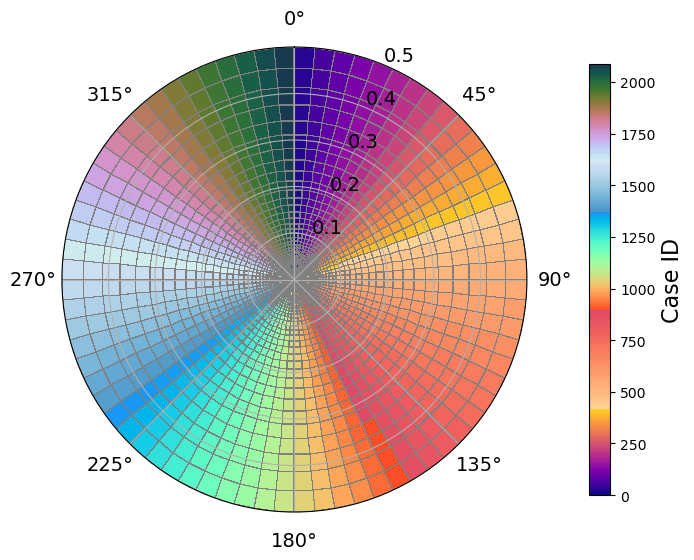

In [19]:
from bluemath_tk.waves.binwaves import plot_selected_cases_grid

# Plot the cases grid. Specific directions sectors can be specified.
plot_selected_cases_grid(
    frequencies=np.unique(swan_cases_df["freq"]),
    directions=np.unique(swan_cases_df["dir"]),
    figsize=(8, 8),
)

In [20]:
from bluemath_tk.wrappers.swan.swan_wrapper import generate_fixed_parameters

fixed_parameters = generate_fixed_parameters(grid_parameters, freq, dir)
fixed_parameters

Distribución direccional: CIRCLE


{'xpc': np.float64(-76.75292574813366),
 'ypc': np.float64(33.86146458260569),
 'alpc': 41,
 'xlenc': 3.0,
 'ylenc': 2,
 'mxc': 719,
 'myc': 479,
 'xpinp': np.float64(-78.61041666666667),
 'ypinp': np.float64(33.55208333333333),
 'alpinp': 0,
 'mxinp': 1106,
 'myinp': 947,
 'dxinp': np.float64(0.004166666666662877),
 'dyinp': np.float64(0.004166666666677088),
 'dir_dist': 'CIRCLE',
 'dir1': None,
 'dir2': None,
 'freq_discretization': 29,
 'dir_discretization': 72,
 'mdc': 72,
 'flow': 0.035,
 'fhigh': 0.5}

In [21]:
import os
from bluemath_tk.wrappers.swan.swan_wrapper import BinWavesWrapper

swan_wrapper = BinWavesWrapper(
    templates_dir="templates",
    metamodel_parameters=swan_cases_df.to_dict(orient="list"),
    fixed_parameters=fixed_parameters,
    output_dir="CASES",
    depth_array=cropped_bathy.values,
    locations=locations.T,
)

2025-12-12 10:32:56,644 - BinWavesWrapper - WARNING - Parameter dir is not in the default_parameters
2025-12-12 10:32:56,644 - BinWavesWrapper - WARNING - Parameter freq is not in the default_parameters
2025-12-12 10:32:56,645 - BinWavesWrapper - WARNING - Parameter hs is not in the default_parameters
2025-12-12 10:32:56,645 - BinWavesWrapper - WARNING - Parameter tp is not in the default_parameters
2025-12-12 10:32:56,646 - BinWavesWrapper - WARNING - Parameter spr is not in the default_parameters
2025-12-12 10:32:56,646 - BinWavesWrapper - WARNING - Parameter gamma is not in the default_parameters


In [22]:
# # Build the input files
# swan_wrapper.build_cases(mode="one_by_one")
# swan_cases_df.to_csv(os.path.join("CASES", "swan_cases.csv"), index=False)

## Execute SWAN

> ⏰ **Note:** To monitor the progress of your runs, you can execute the following cell anytime to check how many SWAN cases have completed (100% simulation finished).  
> It may take a while for the first cases to finish, so feel free to run the cell multiple times to stay updated.  
> Once all cases have reached 100%, you can proceed with the rest of the code.  
> You can also run the next cells even if only a few cases have completed, to check that everything is working as expected.



In [23]:
swan_wrapper.load_cases()

In [24]:
# # Run the model
# # Note: SLURM MaxArraySize is 1001, so we need to split into multiple arrays
# # Array 1: cases 0-1000 (1001 tasks) - uses array indices 0-1000
# swan_wrapper.run_cases_bulk(
#     launcher="sbatch --array=0-999%45 sbatch_example.sh"
# )

# swan_wrapper.run_cases_bulk(
#     launcher="sbatch --array=0-999%45 sbatch_example_1001.sh"
# )

# # Array 3: cases 2000-2087 (88 tasks) - uses array indices 0-87 with offset
# swan_wrapper.run_cases_bulk(
#     launcher="sbatch --array=0-87%45 sbatch_example_2001.sh"
# )
# # swan_wrapper.run_cases_in_background(launcher="/software/geocean/swan/swan_serial.exe", num_workers=15)

In [25]:
swan_wrapper.monitor_cases(value_counts="simple")

Status 
100 %      1583
99.50 %     179
98.94 %       7
99.07 %       6
99.08 %       6
           ... 
99.29 %       1
99.32 %       1
99.30 %       1
99.39 %       1
99.49 %       1
Name: count, Length: 148, dtype: int64

In [26]:
# Post-process the output files
cases_bulk_parameters = swan_wrapper.postprocess_cases()
cases_bulk_parameters

<xarray.Dataset> Size: 9GB
Dimensions:   (case_num: 2088, Yp: 480, Xp: 720)
Coordinates:
  * Xp        (Xp) float32 3kB -76.75 -76.75 -76.75 ... -74.5 -74.49 -74.49
  * Yp        (Yp) float32 2kB 33.86 33.86 33.87 33.87 ... 35.36 35.37 35.37
  * case_num  (case_num) int64 17kB 0 1 2 3 4 5 ... 2083 2084 2085 2086 2087
Data variables:
    Hsig      (case_num, Yp, Xp) float32 3GB 0.001615 0.001623 ... 0.1298 0.1298
    Tm02      (case_num, Yp, Xp) float32 3GB 28.57 28.57 28.57 ... 1.213 1.213
    Dir       (case_num, Yp, Xp) float32 3GB 30.73 30.66 30.62 ... 354.9 354.9

/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/core/operations.py:349: RuntimeWarning: invalid value encountered in multiply
  x_rad = x_deg * np.pi / 180
/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-fork/lib/python3.11/site-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


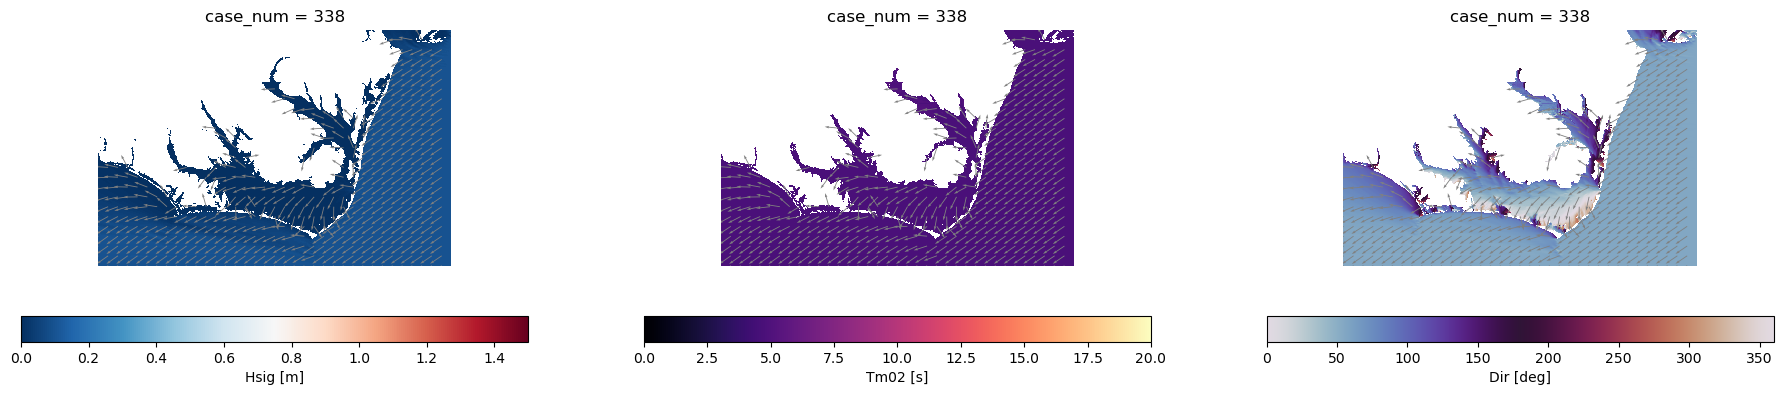

In [27]:
from plotting import plot_case_variables

plot_case_variables(
    data=cases_bulk_parameters.isel(case_num=338),
    step=20,
)

## Plot ALL pre-run cases

/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-fork/lib/python3.11/site-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


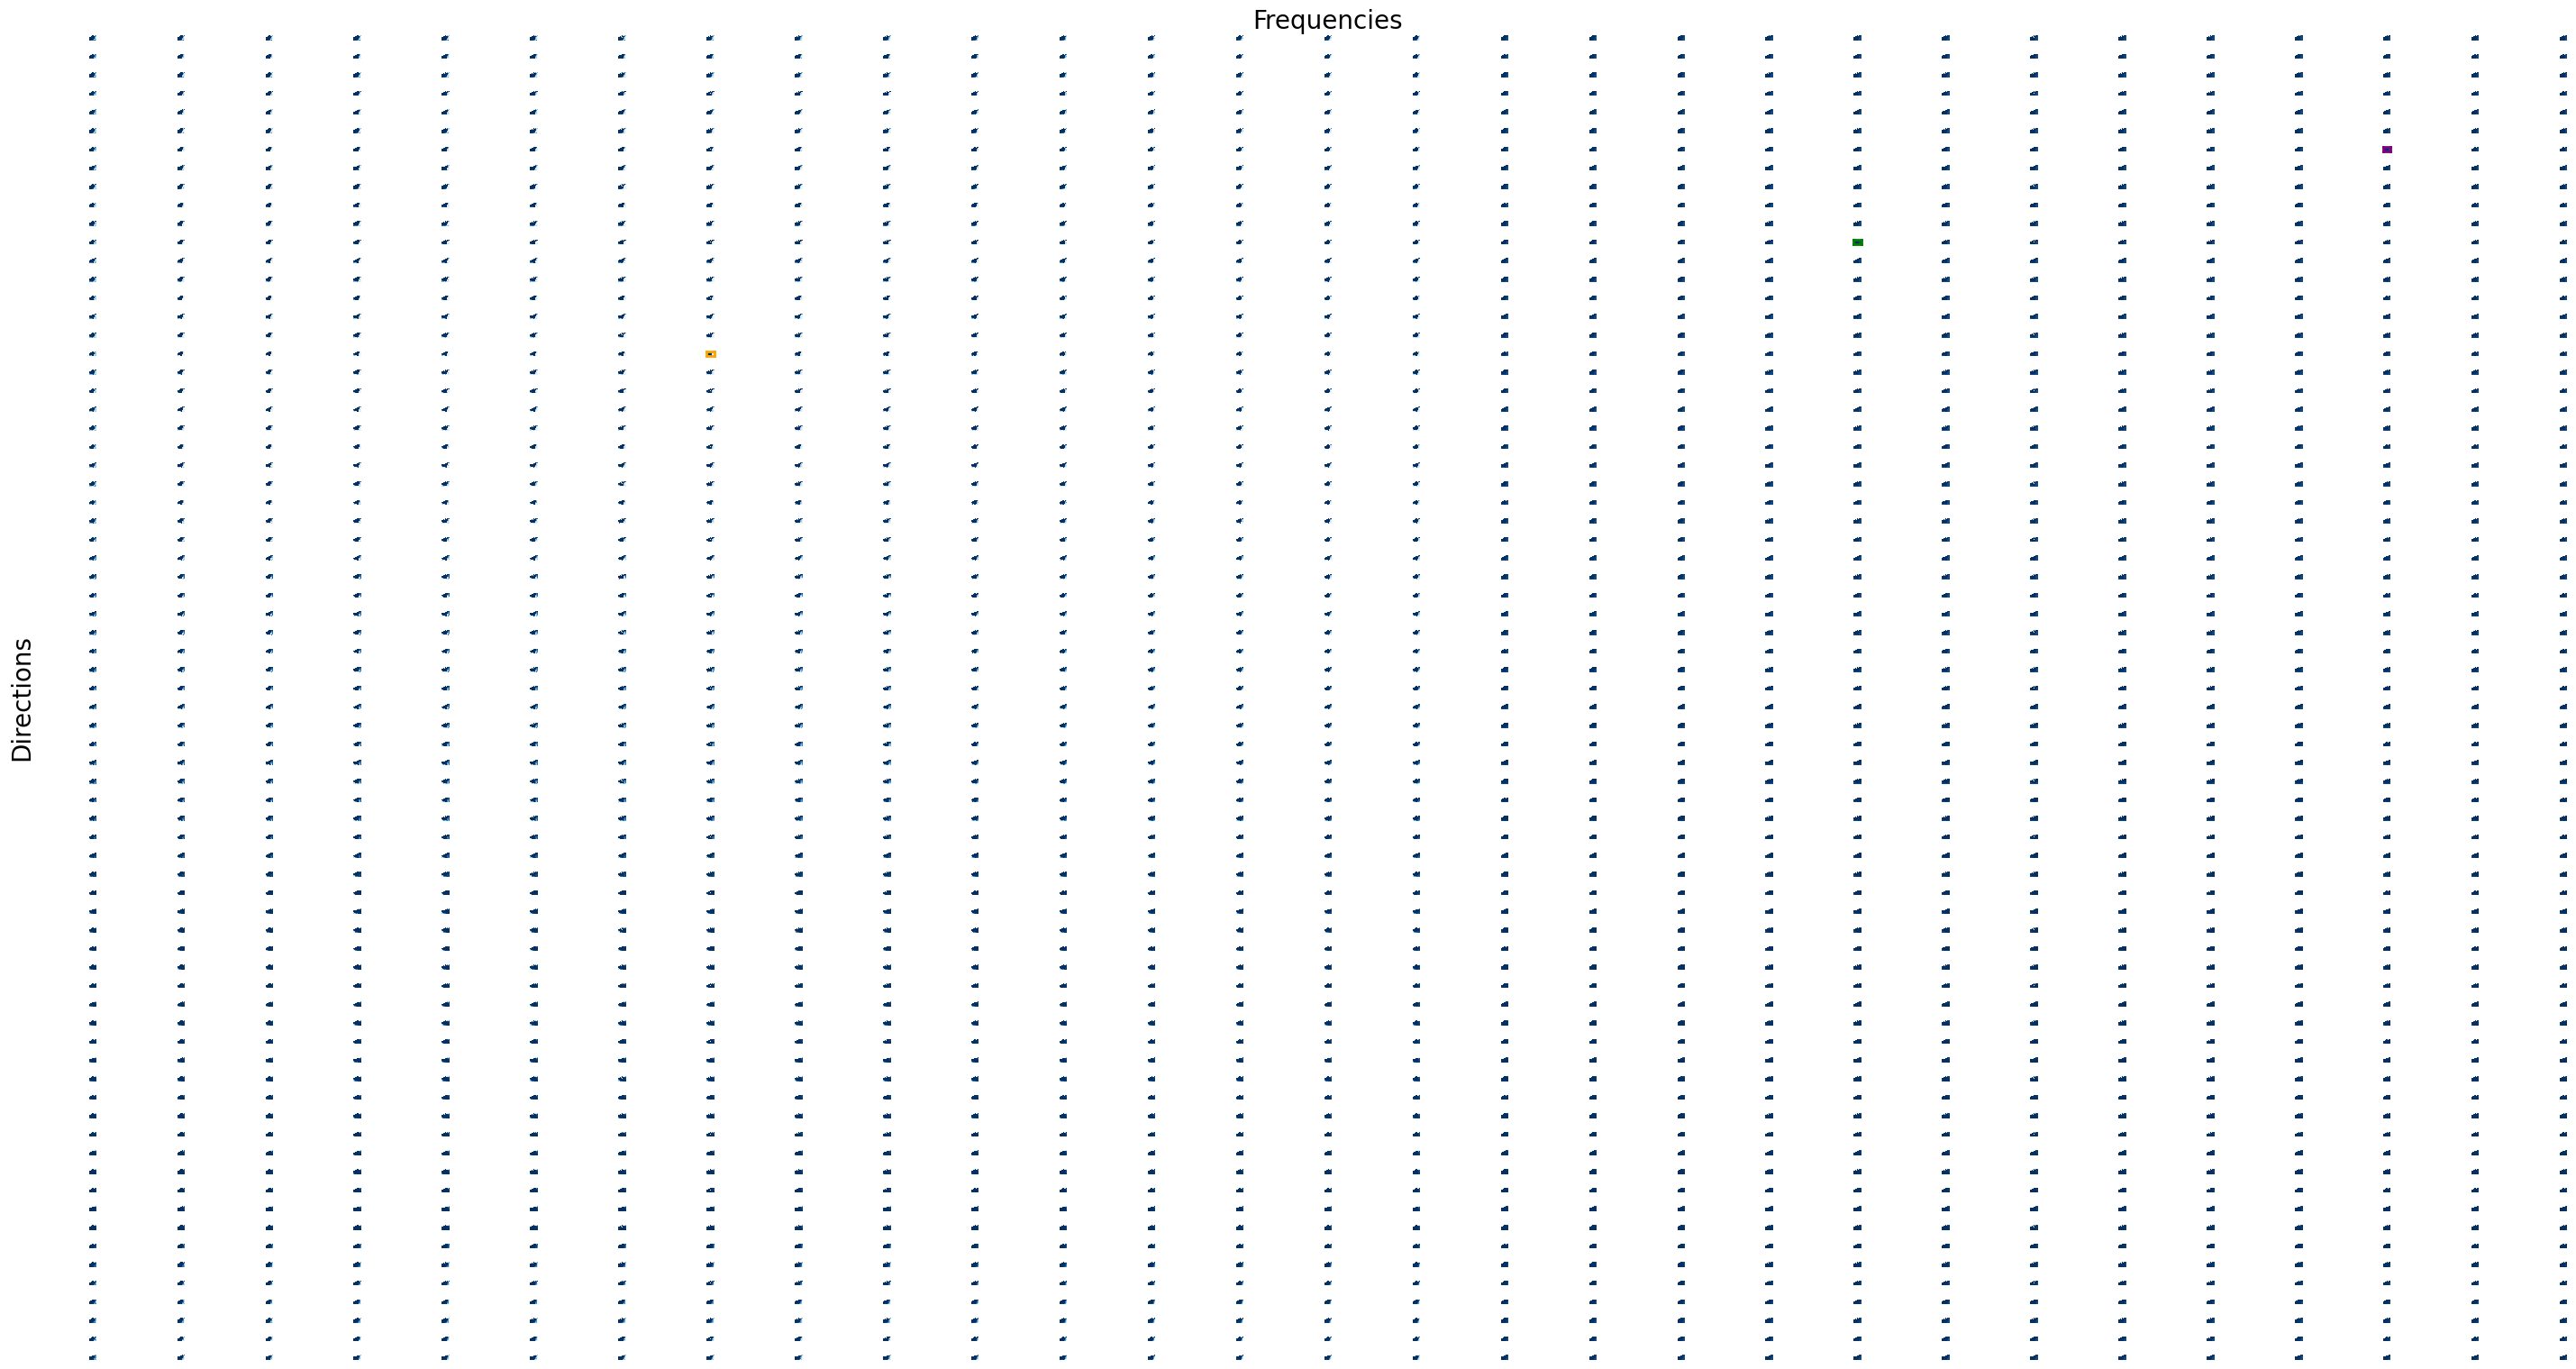

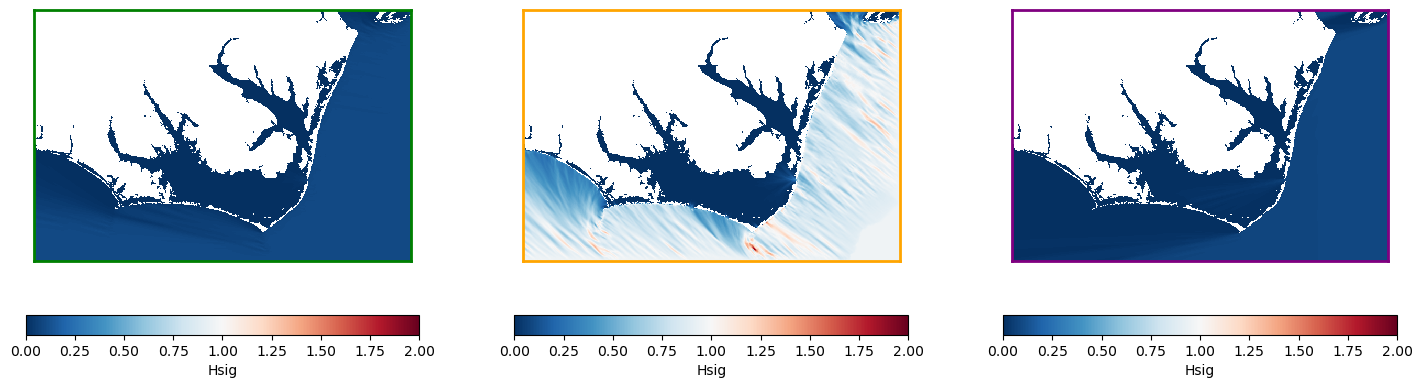

In [28]:
from plotting import plot_cases_grid

# Hsig is already scaled in cases_bulk_parameters (scaled by 10 for periods < 5s)
plot_cases_grid(
    data=cases_bulk_parameters.Hsig,
    cases_to_plot=[339, 500, 200],
    num_directions=len(swan_cases_df["dir"].unique()),
    num_frequencies=len(swan_cases_df["freq"].unique()),
)

## Extract kp coefficients

In [29]:
from bluemath_tk.waves.binwaves import process_kp_coefficients

# list_of_input_spectra = [
#     os.path.join(case_dir, "input_spectra_N.bnd")
#     for case_dir in swan_wrapper.cases_dirs
# ]
# list_of_output_spectra = [
#     os.path.join(case_dir, "output.spec") for case_dir in swan_wrapper.cases_dirs
# ]

# kp_coefficients = process_kp_coefficients(
#     list_of_input_spectra=list_of_input_spectra,
#     list_of_output_spectra=list_of_output_spectra,
# )
# kp_coefficients

list_of_input_spectra = [
    os.path.join(case_dir, "input_spectra_N.bnd")
    for case_dir in swan_wrapper.cases_dirs
]
list_of_output_spectra = [
    os.path.join(case_dir, "output.spec") for case_dir in swan_wrapper.cases_dirs
]

# Process in batches to reduce memory usage
# Also reduce direction resolution from 5° to 15° by averaging
batch_size = 200  # Process 200 cases at a time
direction_group_size = 3  # Group every 3 directions (5° * 3 = 15°)

print(f"Processing {len(list_of_input_spectra)} cases in batches of {batch_size}...")
print(f"Reducing direction resolution from 5° to 15° (averaging groups of {direction_group_size})...")

all_batches = []
for i in range(0, len(list_of_input_spectra), batch_size):
    batch_end = min(i + batch_size, len(list_of_input_spectra))
    batch_input = list_of_input_spectra[i:batch_end]
    batch_output = list_of_output_spectra[i:batch_end]
    
    print(f"Processing batch {i//batch_size + 1}/{(len(list_of_input_spectra)-1)//batch_size + 1} (cases {i} to {batch_end-1})...")
    
    # Process this batch
    batch_kp = process_kp_coefficients(
        list_of_input_spectra=batch_input,
        list_of_output_spectra=batch_output,
    )
    
    # Reduce direction resolution by averaging groups of directions
    if "dir" in batch_kp.dims:
        original_dirs = batch_kp.dir.values
        n_dirs = len(original_dirs)
        n_groups = n_dirs // direction_group_size
        remainder = n_dirs % direction_group_size
        
        # Create new direction values representing 15° sectors
        # Each group of 3 directions (5° apart) represents a 15° sector
        # Sector centers are calculated as the midpoint of each group
        new_dirs = []
        batch_kp_reduced = []
        
        for j in range(n_groups):
            start_idx = j * direction_group_size
            end_idx = start_idx + direction_group_size
            group_dirs = original_dirs[start_idx:end_idx]
            
            # Calculate sector center as midpoint of the group
            sector_start = group_dirs[0]
            sector_end = group_dirs[-1] + 5  # Add 5° to get the end of the sector
            sector_center = (sector_start + sector_end) / 2
            new_dirs.append(sector_center)
            
            # Average the group data
            group_avg = batch_kp.isel(dir=slice(start_idx, end_idx)).mean(dim="dir")
            batch_kp_reduced.append(group_avg)
        
        # Handle remainder directions (if any) by including them in the last group
        if remainder > 0:
            start_idx_last = (n_groups - 1) * direction_group_size
            end_idx = n_dirs
            combined_slice = batch_kp.isel(dir=slice(start_idx_last, end_idx))
            last_group_combined = combined_slice.mean(dim="dir")
            batch_kp_reduced[-1] = last_group_combined
            # Recalculate sector center for the combined group
            combined_dirs = original_dirs[start_idx_last:end_idx]
            sector_start = combined_dirs[0]
            sector_end = combined_dirs[-1] + 5
            sector_center = (sector_start + sector_end) / 2
            new_dirs[-1] = sector_center
        
        # Concatenate along direction dimension
        batch_kp = xr.concat(batch_kp_reduced, dim="dir")
        batch_kp = batch_kp.assign_coords(dir=new_dirs)
        
        print(f"  Reduced directions from {n_dirs} to {len(new_dirs)}")
    
    all_batches.append(batch_kp)

# Concatenate all batches
print("Concatenating all batches...")
kp_coefficients = xr.concat(all_batches, dim="case_num")

# Reassign case_num coordinates to be sequential (0 to total_cases-1)
# Each batch has cases 0-199, but after concatenation we need 0-2087
total_cases = len(kp_coefficients.case_num)
kp_coefficients = kp_coefficients.assign_coords(case_num=np.arange(total_cases))
print(f"Reassigned case_num coordinates to range 0-{total_cases-1}")

print(f"Final kp_coefficients shape (before case aggregation): {kp_coefficients.shape}")
print(f"Final direction resolution: {len(kp_coefficients.dir.values)} directions (15° spacing)")
print(f"Case_num range: {kp_coefficients.case_num.values.min()} to {kp_coefficients.case_num.values.max()}")

# Aggregate cases from 2088 to 696 (24 directions × 29 frequencies)
print(f"\nAggregating cases from {total_cases} to {len(kp_coefficients.dir.values) * 29}...")

# Import utility functions
from kp_averaging import create_averaged_model_parameters, aggregate_kp_coefficients

# Save temporarily to read directions (will be overwritten with aggregated version later)
temp_kp_path = "outputs/kp_coefficients_temp.nc"
kp_coefficients.to_dataset(name="kps").drop_vars(["time"], errors="ignore").assign_coords(
    coord_x=(("site"), swan_wrapper.locations[:, 0]),
    coord_y=(("site"), swan_wrapper.locations[:, 1]),
).to_netcdf(temp_kp_path)

# Create averaged model parameters and case mapping
original_csv_path = "CASES/swan_cases.csv"
model_params, case_num_mapping = create_averaged_model_parameters(
    original_csv_path=original_csv_path,
    kp_coefficients_path=temp_kp_path,
    direction_group_size=direction_group_size,
)

# Aggregate kp coefficients
kp_coefficients_aggregated = aggregate_kp_coefficients(
    kp_coeffs=kp_coefficients,
    case_num_mapping=case_num_mapping,
)

# Create new swan_cases.csv with 696 cases
import pandas as pd
swan_cases_averaged = pd.DataFrame({
    'dir': model_params['dir'],
    'freq': model_params['freq'],
    'hs': model_params['hs'],
    'tp': model_params['tp'],
    'spr': model_params['spr'],
    'gamma': model_params['gamma'],
})
swan_cases_averaged['case_num'] = swan_cases_averaged.index
swan_cases_averaged.to_csv("CASES/swan_cases_averaged.csv", index=False)

print(f"Created swan_cases_averaged.csv with {len(swan_cases_averaged)} cases")
print(f"Final kp_coefficients shape (after aggregation): {kp_coefficients_aggregated.shape}")
print(f"Final case_num range: {kp_coefficients_aggregated.case_num.values.min()} to {kp_coefficients_aggregated.case_num.values.max()}")

# Update kp_coefficients to the aggregated version
kp_coefficients = kp_coefficients_aggregated

# Clean up temp file
import os
if os.path.exists(temp_kp_path):
    os.remove(temp_kp_path)

kp_coefficients


Processing 2088 cases in batches of 200...
Reducing direction resolution from 5° to 15° (averaging groups of 3)...
Processing batch 1/11 (cases 0 to 199)...
  Reduced directions from 72 to 24
Processing batch 2/11 (cases 200 to 399)...
  Reduced directions from 72 to 24
Processing batch 3/11 (cases 400 to 599)...
  Reduced directions from 72 to 24
Processing batch 4/11 (cases 600 to 799)...
  Reduced directions from 72 to 24
Processing batch 5/11 (cases 800 to 999)...
  Reduced directions from 72 to 24
Processing batch 6/11 (cases 1000 to 1199)...
  Reduced directions from 72 to 24
Processing batch 7/11 (cases 1200 to 1399)...
  Reduced directions from 72 to 24
Processing batch 8/11 (cases 1400 to 1599)...
  Reduced directions from 72 to 24
Processing batch 9/11 (cases 1600 to 1799)...
  Reduced directions from 72 to 24
Processing batch 10/11 (cases 1800 to 1999)...
  Reduced directions from 72 to 24
Processing batch 11/11 (cases 2000 to 2087)...
  Reduced directions from 72 to 24
Conc

<xarray.DataArray 'efth' (case_num: 696, dir: 24, site: 2651, freq: 29)> Size: 10GB
array([[[[2.31370831e-07, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [1.98708821e-06, 9.85586983e-10, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [2.60331007e-09, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [8.99482410e-01, 3.59068709e-04, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [9.11318819e-01, 3.89033114e-04, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [9.05978327e-01, 3.85247355e-04, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

        [[3.27193828e-06, 1.52503857e-09, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [6.26967951e-07, 2.46396746e-10, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [1.69280782e-07, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
...
          0.00000000e+00, 0.00000000e+00, 5.09174942e-02],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 8.52927764e-02],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 7.73637338e-02]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 4.97688696e-01],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 7.25146963e-01],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 6.76586703e-01]]]],
      shape=(696, 24, 2651, 29))
Coordinates:
  * site      (site) int64 21kB 1 2 3 4 5 6 7 ... 2646 2647 2648 2649 2650 2651
  * freq      (freq) float64 232B 0.035 0.0385 0.0423 ... 0.4135 0.4547 0.5
    lat       float64 8B 0.0
    lon       float64 8B 0.0
  * dir       (dir) float64 192B 9.0 24.0 39.0 54.0 ... 309.0 324.0 339.0 354.0
  * case_num  (case_num) int64 6kB 0 1 2 3 4 5 6 ... 689 690 691 692 693 694 695

In [30]:
# Save aggregated kp_coefficients (24 directions × 696 cases)
# This file now contains only 696 cases, matching swan_cases_averaged.csv
kp_coefficients.to_dataset(name="kps").drop_vars(["time"], errors="ignore").assign_coords(
    coord_x=(("site"), swan_wrapper.locations[:, 0]),
    coord_y=(("site"), swan_wrapper.locations[:, 1]),
).to_netcdf("outputs/kp_coefficients_averaged.nc")